# Imports

In [1]:
import cpa
import os
import sys
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import energy_distance
from typing import Optional
from collections import defaultdict


sc.settings.set_figure_params(dpi=100)
# Enables detailed logs during processing.
sc.settings.verbosity = 3 

Global seed set to 0


# Data Setup and Visualization

| Column               | Meaning                                                                                       |
|----------------------|-----------------------------------------------------------------------------------------------|
| **sample**           | A unique identifier for each biological sample or well—often encodes cell line, drug, dose.   |
| **gene_count**       | Number of genes detected (non-zero) in that cell.                                             |
| **tscp_count**       | Total UMI counts (total transcripts) per cell.                                                |
| **mread_count**      | Number of mapped reads for that cell (before UMI collapsing).                                 |
| **drugname_drugconc**| The compound name and the concentration (e.g. `Dabrafenib_1uM`).                              |
| **drug**             | The compound name only (e.g. `Dabrafenib`).                                                   |
| **cell_line**        | Which cancer cell line that cell came from (e.g. `MCF7`, `A549`).                             |
| **sublibrary**       | Which sublibrary/index it was sequenced in (one of the ~1 700 pools).                         |
| **BARCODE**          | The single-cell barcode sequence (unique within a library).                                   |
| **pcnt_mito**        | Percent of transcripts mapping to mitochondrial genes—a QC metric.                            |
| **S_score**          | A cell-cycle score for S-phase genes (higher = more S-phase expression).                      |
| **G2M_score**        | A cell-cycle score for G2/M-phase genes (higher = more G2/M expression).                      |
| **phase**            | Discrete cell-cycle assignment (`G1`, `S`, `G2M`) based on those scores.                      |
| **pass_filter**      | Boolean flag: did this cell pass your QC filters?                                            |
| **cell_name**        | A human-readable name—often a concatenation of cell line + barcode.                           |
| **plate**            | Which 96-well plate the spheroid or sample originated from.                                   |


In [2]:
data_path = './plate9_for_cpa_RDkit_training.h5ad'

adata = sc.read('./plate9_for_cpa_RDkit_training.h5ad')      
adata.obs['drug'] = adata.obs['condition_ID'].str.split('_', n=1).str[0]

print("Number of cells:", adata.n_obs)
print("Number of unique drugs:", adata.obs['drug'].nunique())
print("Example drug names:", adata.obs['drug'].unique()[:10].tolist())

Number of cells: 17087
Number of unique drugs: 86
Example drug names: ['Sivelestat (sodium tetrahydrate)', 'Posaconazole', 'Tetracycline (hydrochloride)', 'Entecavir (monohydrate)', 'Sildenafil', 'Dimethyl fumarate', 'Berbamine (dihydrochloride)', 'Daidzin', 'Fumaric acid', 'Pravastatin (sodium)']


# Split the data

split_1ct_MEC
train    14687
ood       1600
valid      800
Name: count, dtype: int64
-> OOD conditions:
['Almonertinib (mesylate)_50uM', 'Bisoprolol (hemifumarate)_50uM', 'Clofarabine_50uM', 'Cytarabine_50uM', 'Lucanthone_50uM', 'Rucaparib (phosphate)_50uM', 'Sivelestat (sodium tetrahydrate)_50uM', 'Tranilast_50uM']
computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA


    with n_comps=50
    finished (0:00:01)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:25)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:16)


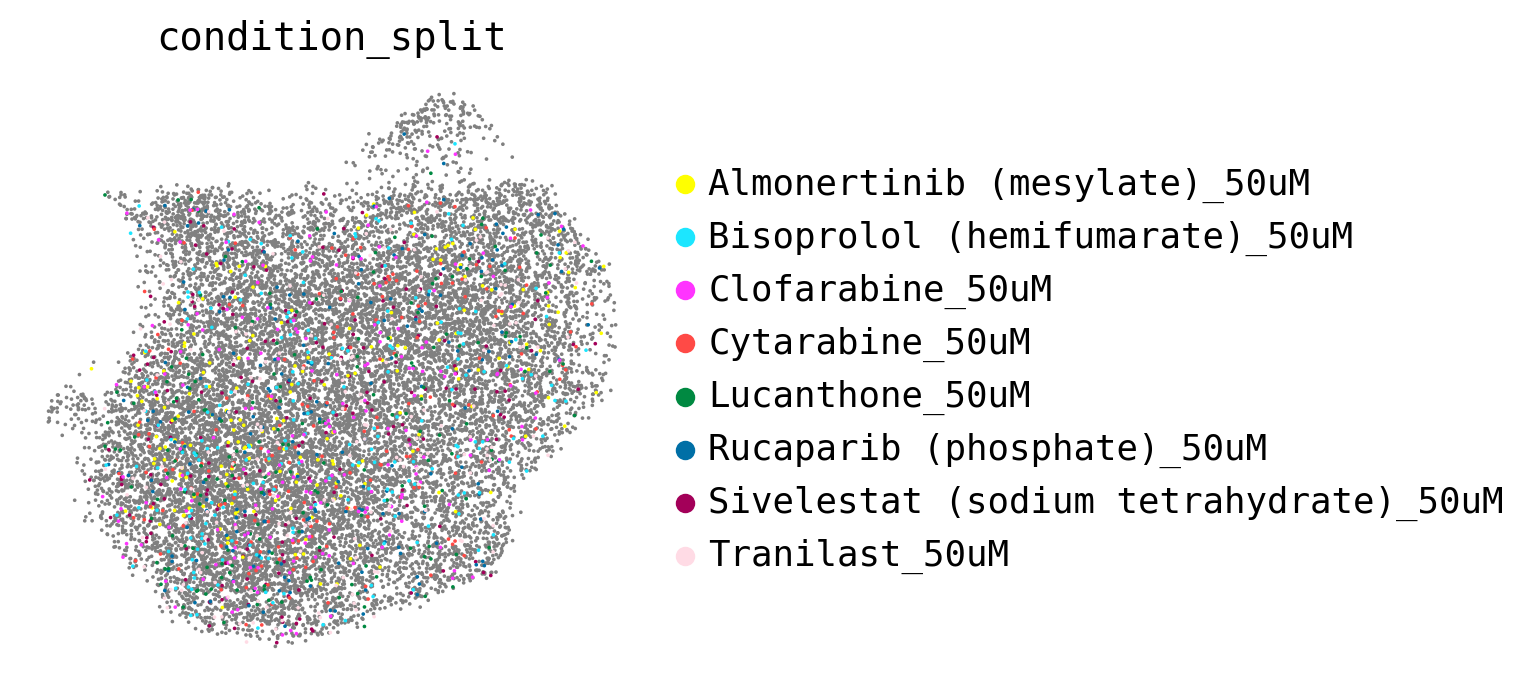

In [4]:
# Define Data Splits (split_1ct_MEC)
np.random.seed(42)
conds = adata.obs["condition_ID"].unique().tolist()
n_ood = max(1, int(0.1 * len(conds)))
ood_conds = np.random.choice(conds, n_ood, replace=False)

# initialize all as train
adata.obs["split_1ct_MEC"] = "train"
# mark OOD drugs
mask = adata.obs["condition_ID"].isin(ood_conds)
adata.obs.loc[mask, "split_1ct_MEC"] = "ood"

# carve out a small validation set
val_conds = np.random.choice(
    [c for c in conds if c not in ood_conds],
    max(1, int(0.05 * len(conds))),
    replace=False
)
mask_val = adata.obs["condition_ID"].isin(val_conds)
adata.obs.loc[mask_val, "split_1ct_MEC"] = "valid"

print(adata.obs['split_1ct_MEC'].value_counts())

# count of cells in each data split
ood_conds = list(adata[adata.obs['split_1ct_MEC'] == 'ood'].obs['condition_ID'].value_counts().index)

# Gathers all unique condition IDs from the OOD split,
# used later for visualization and prediction.
print("-> OOD conditions:")
print(ood_conds) 

# Tags each cell's condition as either an OOD condition or 'other'. 
# Useful for color-coding the UMAP plot.
adata.obs['condition_split'] = adata.obs['condition_ID'].apply(lambda x: x if x in ood_conds else 'other')

# Calculate Neighbors and UMAP
sc.pp.neighbors(adata) 

# UMAP: Projects high-dimensional gene expression into 2D space for visualization.
sc.tl.umap(adata) 

# Visualize UMAP by condition
sc.pl.umap(adata,
           color='condition_split', #Plots UMAP embedding, colored by condition_split.
           groups=ood_conds,
           palette=sc.pl.palettes.godsnot_102,
           na_in_legend=False,
           na_color='grey', #Only shows the OOD groups explicitly; others are gray 
           frameon=False)


# Data setup

In [3]:
cpa.CPA.setup_anndata(adata,
                      perturbation_key='condition_ID', #defines perturbation conditions
                      dosage_key='log_dose',           #for dose-dependent effects.
                      control_group='DMSO_TF_00uM',
                      batch_key=None,
                      smiles_key='smiles_rdkit',       #to compute RDKit embeddings, which capture chemical structure.
                      is_count_data=True,              #raw counts
                      categorical_covariate_keys=['cell_line'], #CPA can model how cell type affects drug response.
                      deg_uns_key='rank_genes_groups', #where CPA can find differential expression gene lists in .uns.
                      deg_uns_cat_key='cov_drug_dose',               #cov_drug_dose on the groupby of DE 
                      max_comb_len=1,
                     )

100%|██████████| 86/86 [00:00<00:00, 14318.44it/s]


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


# Training CPA

In [94]:
ae_hparams = {'n_latent': 256,  #are technical parameters of the architecture of the autoencoder. number of latent dimensions for the autoencoder
 'recon_loss': 'nb',           #the type of reconstruction loss function to use, Use negative binomial loss, appropriate for count data like scRNA-seq.
 'doser_type': 'linear',       #the type of doser to use
 'n_hidden_encoder': 512,      #number of hidden neurons in each hidden layer of the encoder
 'n_layers_encoder': 2,        #number of hidden layers in the encoder
 'n_hidden_decoder': 512,      #number of hidden neurons in each hidden layer of the decoder
 'n_layers_decoder': 2,        #number of hidden layers in the decoder
 'use_batch_norm_encoder': True,  #if True, batch normalization will be used in the encoder
 'use_layer_norm_encoder': False, #if True, layer normalization will be used in the encoder
 'use_batch_norm_decoder': True,  #if True, batch normalization will be used in the decoder
 'use_layer_norm_decoder': False, #if True, layer normalization will be used in the decoder
 'dropout_rate_encoder': 0.05,    #dropout rate used in the encoder, Regularization to prevent overfitting.
 'dropout_rate_decoder': 0.05,    #dropout rate used in the decoder
 'variational': False,            #if True, variational autoencoder will be employed as the main perturbation response predictor, Not using a variational autoencoder (VAE) — purely deterministic.
 'seed': 6478}                    #number for setting the seed for generating random numbers. For reproducibility.


trainer_params = {
    'n_epochs_kl_warmup': None,        # Number of epochs for KL divergence warmup
    'n_epochs_pretrain_ae': 50,        # Number of epochs to pre-train the autoencoder
    'n_epochs_adv_warmup': 100,        # Number of epochs for adversarial warmup
    'n_epochs_mixup_warmup': 10,       # Number of epochs for mixup warmup
    'mixup_alpha': 0.1,                # Mixup interpolation coefficient
    'adv_steps': None,                 # Number of steps to train adversarial classifiers after one AE step
    'n_hidden_adv': 128,               # Number of hidden neurons per hidden layer in adversarial classifiers
    'n_layers_adv': 3,                 # Number of hidden layers in adversarial classifiers
    'use_batch_norm_adv': False,       # Whether to use batch normalization in adversarial classifiers
    'use_layer_norm_adv': False,       # Whether to use layer normalization in adversarial classifiers
    'dropout_rate_adv': 0.2,           # Dropout rate in adversarial classifiers
    'reg_adv': 10.0,                   # Regularization coefficient for adversarial classifiers
    'pen_adv': 0.1,                    # Penalty coefficient for adversarial classifiers
    'lr': 3e-4,                      # Learning rate for the main trainer
    'wd': 4e-07,                       # Weight decay (L2 regularization) for the main trainer
    'adv_lr': 0.0003,                  # Learning rate for adversarial classifiers
    'adv_wd': 4e-07,                   # Weight decay for adversarial classifiers
    'adv_loss': 'cce',                 # Loss function type for adversarial training (e.g., 'cce' = categorical cross-entropy)
    'doser_lr': 0.0003,                # Learning rate for the doser (drug-response curve parameters)
    'doser_wd': 4e-07,                 # Weight decay for the doser parameters
    'do_clip_grad': True,             # Whether to apply gradient clipping
    'gradient_clip_value': 1.0,        # Value to clip gradients to, if clipping is enabled
    'step_size_lr': 10                 # Epoch interval to apply learning rate decay (if applicable)
}



model = cpa.CPA(adata,
                split_key='split_1ct_MEC',
                train_split='train',
                valid_split='valid',
                test_split='ood',
                use_rdkit_embeddings=True,
                **ae_hparams,
               )


MODEL_PATH = "./cpa_RDkit_training_optim_params_2"
model.train(
    max_epochs=2000,                          # Maximum number of epochs to train the model
    use_gpu=False,                            # If True, training will use available GPU
    batch_size=512,                           # Number of samples per mini-batch
    plan_kwargs=trainer_params,               # Training parameters defined in trainer_params
    early_stopping_patience=50,               # Stop training if no improvement after this many epochs
    check_val_every_n_epoch=5,                # Frequency (in epochs) to evaluate on validation set
    save_path=MODEL_PATH                      # Directory to save model checkpoints
)


Global seed set to 6478


(86, 2048)


100%|██████████| 86/86 [00:00<00:00, 241.54it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 5/2000:   0%|          | 4/2000 [00:55<7:49:20, 14.11s/it, v_num=1, recon=268, r2_mean=0.705, adv_loss=4.28, acc_pert=0.0318]


Epoch 00004: cpa_metric reached. Module best state updated.


Epoch 10/2000:   0%|          | 9/2000 [02:13<8:24:30, 15.20s/it, v_num=1, recon=246, r2_mean=0.76, adv_loss=4.12, acc_pert=0.0648, val_recon=319, disnt_basal=0.264, disnt_after=0.937, val_r2_mean=0.827, val_KL=nan]
disnt_basal = 0.26271814834695273
disnt_after = 0.38972411284162173
val_r2_mean = 0.8499412089586258
val_r2_var = 0.2244822233915329
Epoch 20/2000:   1%|          | 19/2000 [04:40<8:31:48, 15.50s/it, v_num=1, recon=225, r2_mean=0.814, adv_loss=3.96, acc_pert=0.0909, val_recon=245, disnt_basal=0.261, disnt_after=0.307, val_r2_mean=0.909, val_KL=nan]
disnt_basal = 0.2596904147713861
disnt_after = 0.2901350511855256
val_r2_mean = 0.9424536675214767
val_r2_var = 0.7068003788590431
Epoch 30/2000:   1%|▏         | 29/2000 [07:29<9:13:04, 16.84s/it, v_num=1, recon=213, r2_mean=0.841, adv_loss=3.85, acc_pert=0.111, val_recon=235, disnt_basal=0.259, disnt_after=0.283, val_r2_mean=0.957, val_KL=nan] 
disnt_basal = 0.25838574188461316
disnt_after = 0.27918000854345704
val_r2_mean = 0.

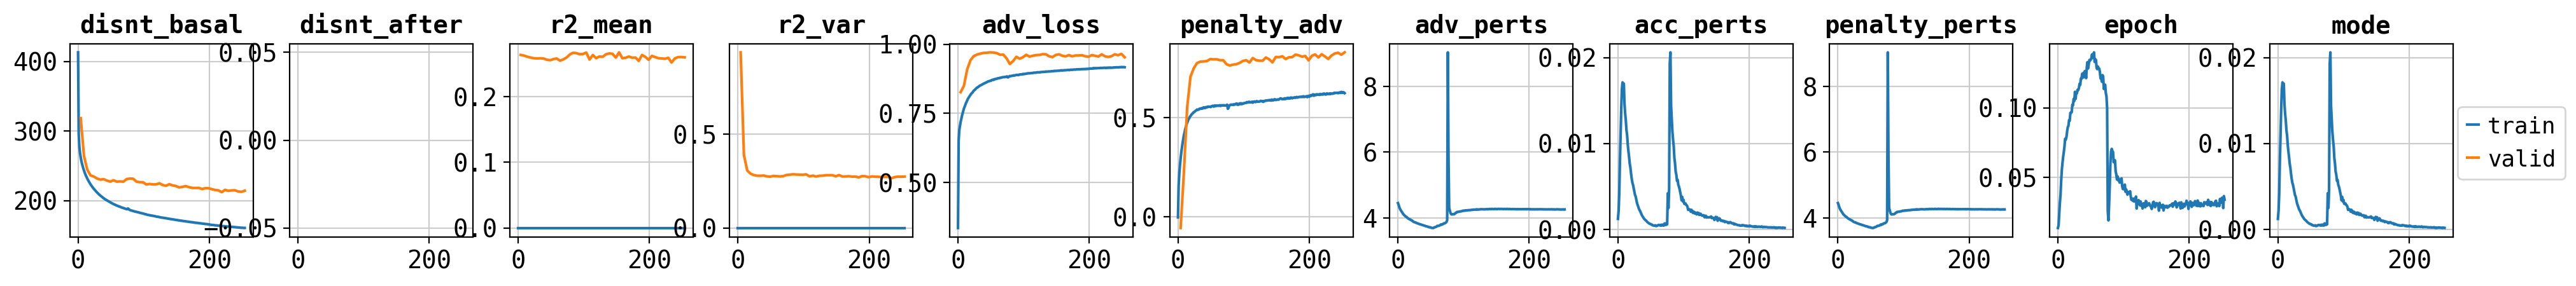

In [95]:
cpa.pl.plot_history(model)

## restore model

In [96]:
# model = cpa.CPA.load(dir_path='./cpa_RDkit_training_optim_params_final', adata=adata, use_gpu=False)

## Latent space UMAP visualization

In [123]:
latent_outputs = model.get_latent_representation(adata, batch_size=1024)
latent_basal_adata = latent_outputs['latent_basal']
latent_adata = latent_outputs['latent_after']
sc.pp.neighbors(latent_basal_adata)
sc.tl.umap(latent_basal_adata)


100%|██████████| 17/17 [00:01<00:00, 11.63it/s]


computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


In [124]:
latent_basal_adata

AnnData object with n_obs × n_vars = 17087 × 256
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition_ID', 'dose', 'log_dose', 'cell_type', 'cov_drug_dose', 'n_counts', 'drug_cleaned', 'drug_norm', 'smiles_rdkit', 'split_1ct_MEC', 'condition_split', 'CPA_cat', 'CPA_DMSO_TF_00uM', '_scvi_condition_ID', '_scvi_cell_line', '_scvi_CPA_cat'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

## Basal Latent

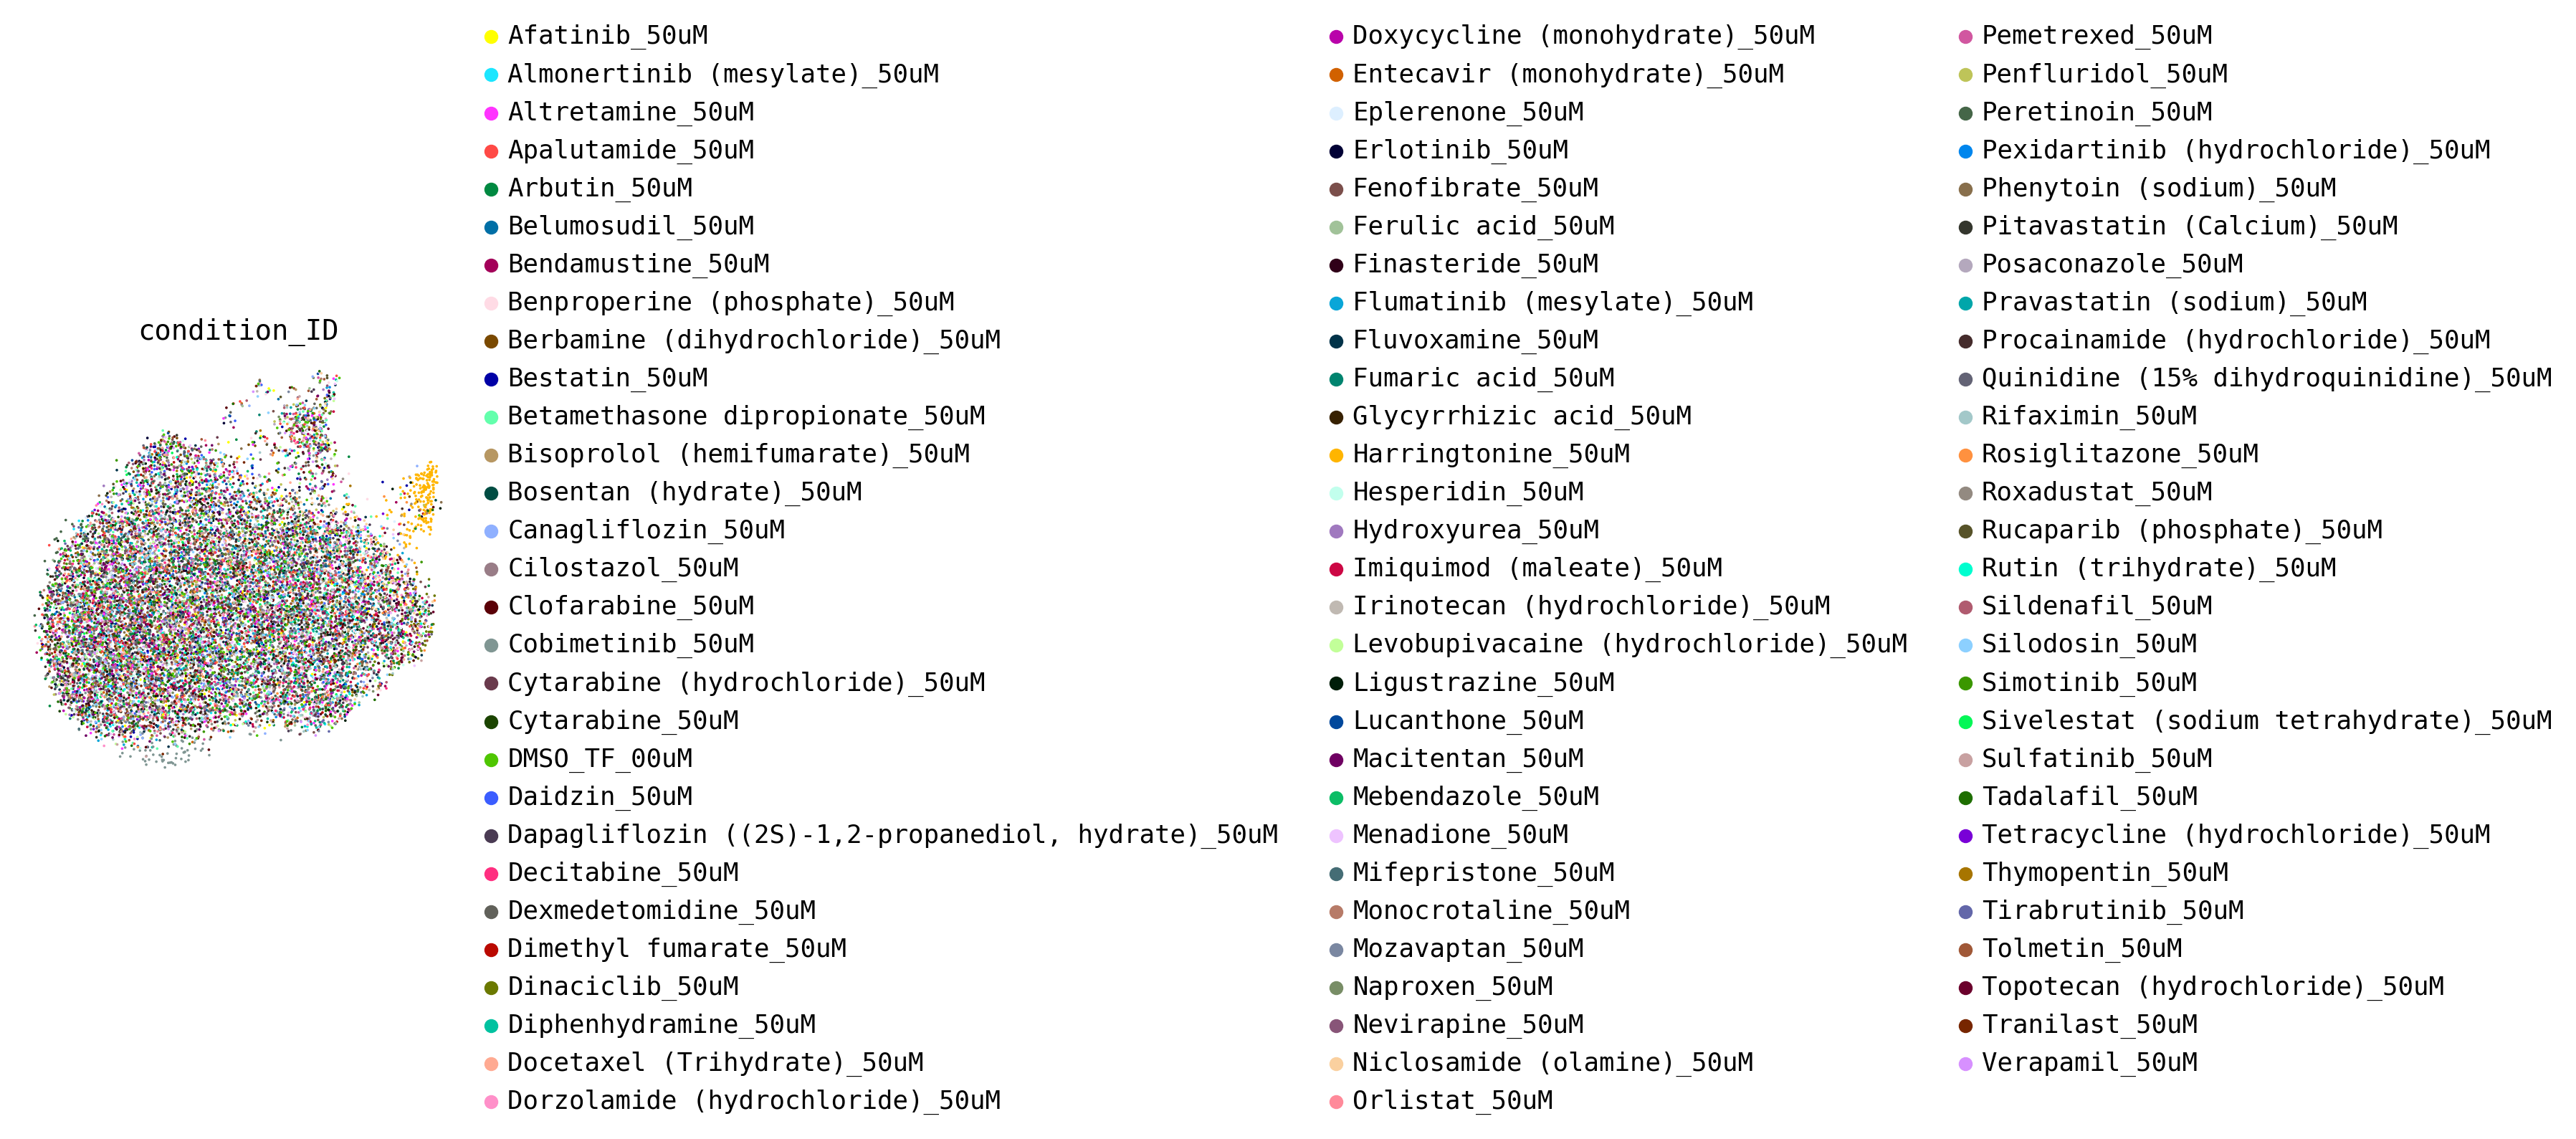

In [125]:
sc.pl.umap(latent_basal_adata, color=['condition_ID'], frameon=False, wspace=0.2)

In [126]:
print(adata.obs['condition_ID'].value_counts())


condition_ID
DMSO_TF_00uM                         329
Afatinib_50uM                        200
Mozavaptan_50uM                      200
Pexidartinib (hydrochloride)_50uM    200
Peretinoin_50uM                      200
                                    ... 
Dimethyl fumarate_50uM               200
Simotinib_50uM                       170
Niclosamide (olamine)_50uM           142
Dinaciclib_50uM                      126
Topotecan (hydrochloride)_50uM       120
Name: count, Length: 86, dtype: int64


In [127]:
sc.pp.neighbors(latent_adata)
sc.tl.umap(latent_adata)

computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


## Final Latent

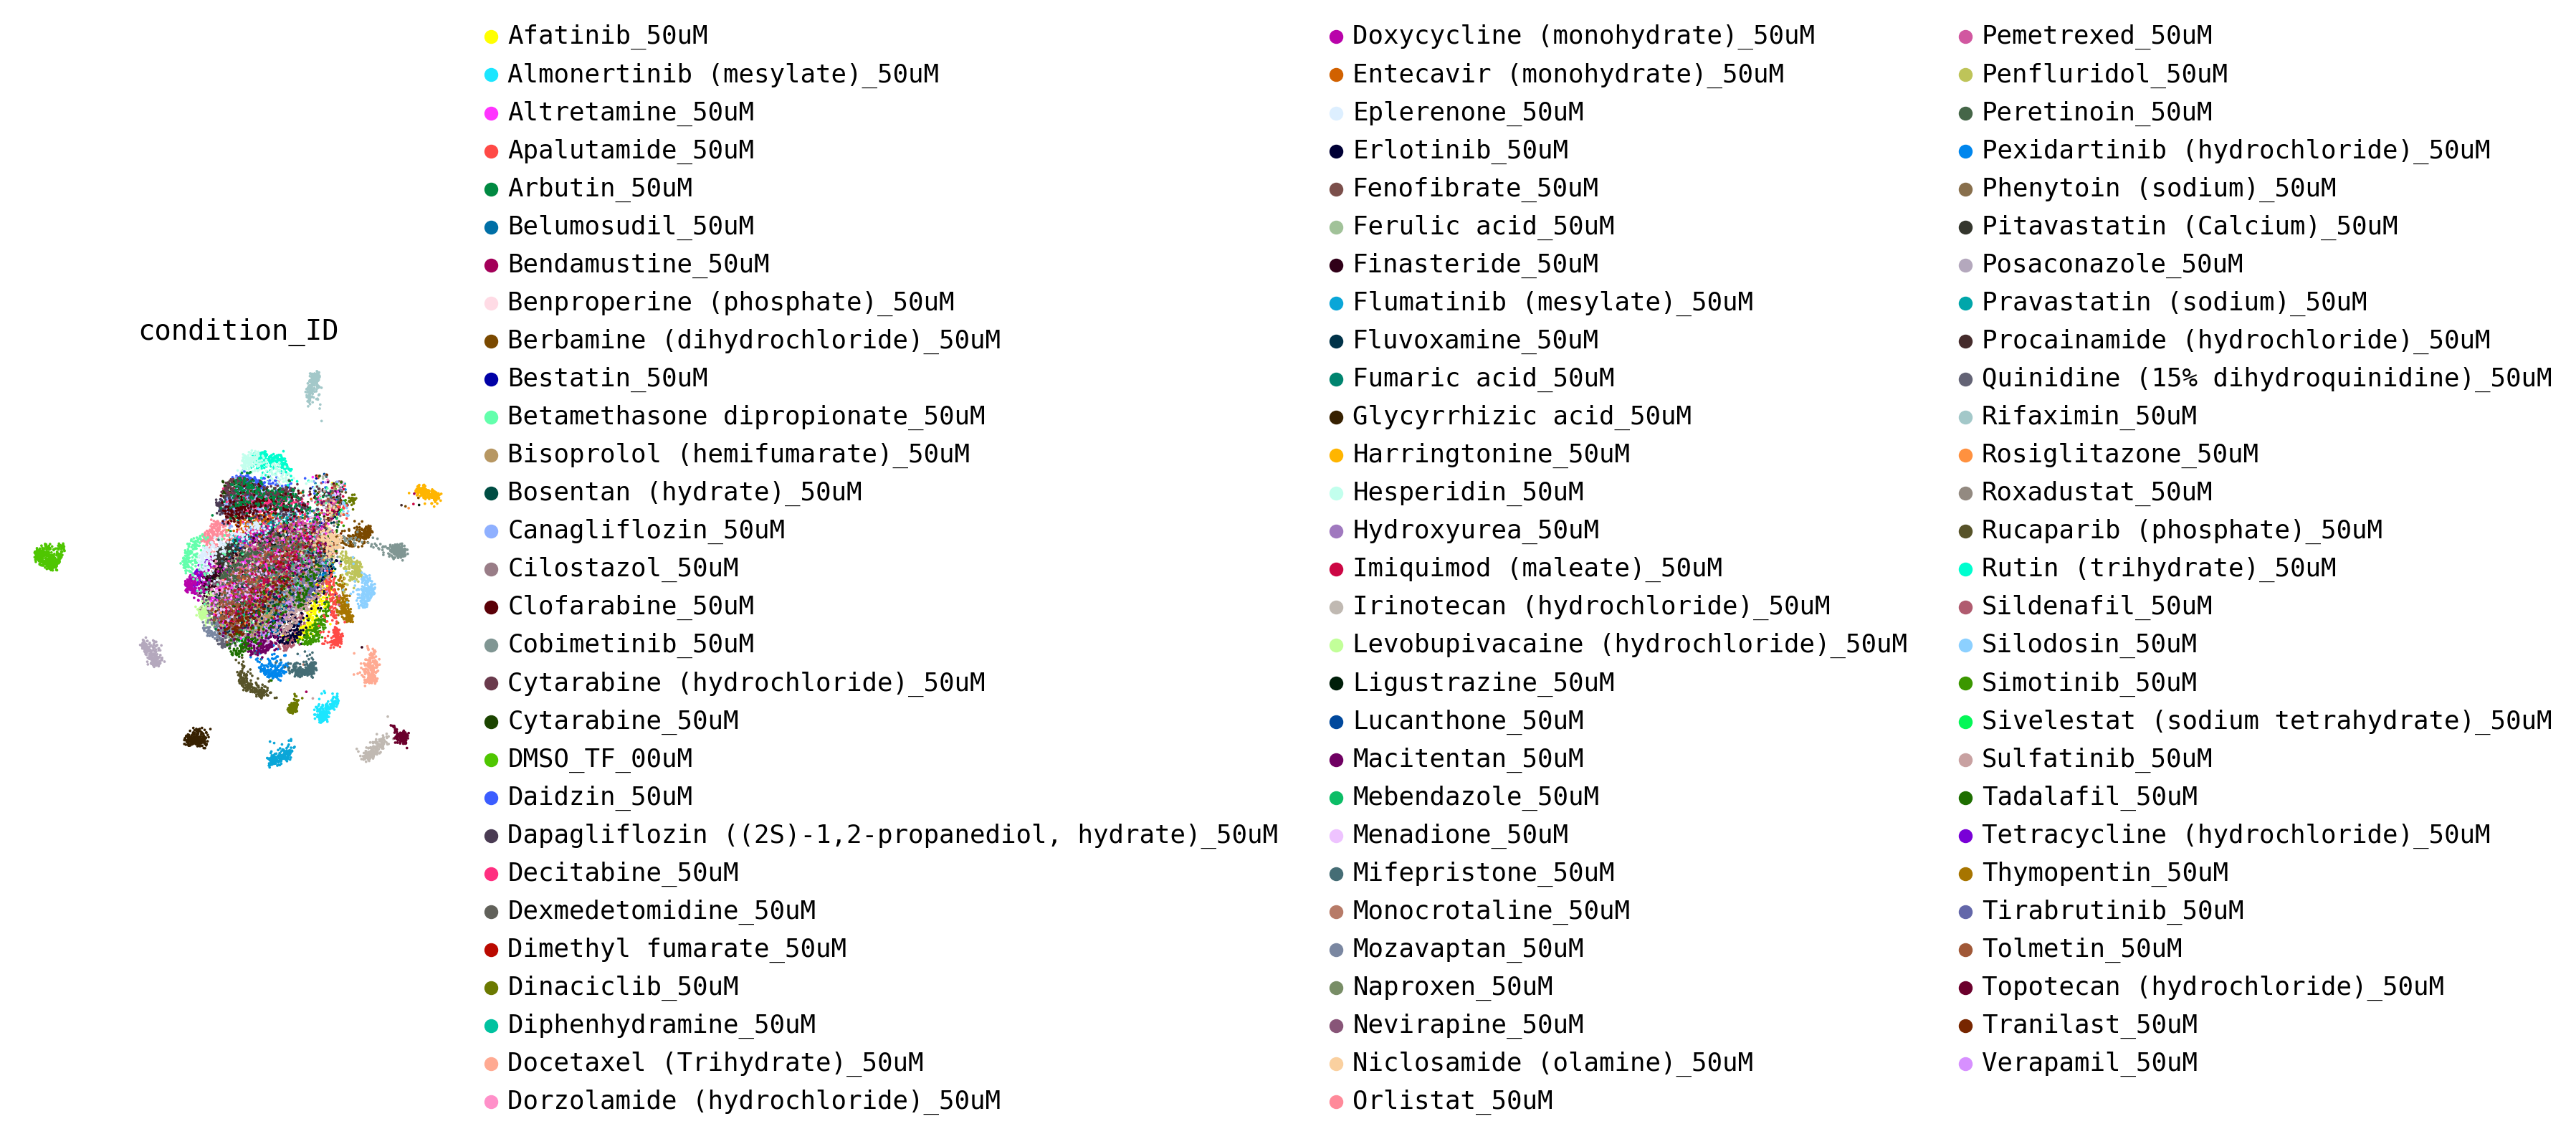

In [128]:
sc.pl.umap(latent_adata, color=['condition_ID'], frameon=False, wspace=0.2)


## Evaluation

In [129]:
model.predict(adata, batch_size=1024)


  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:02<00:00,  7.56it/s]


In [130]:
n_top_degs = [10, 20, 50, None] # None means all genes

results = defaultdict(list)
ctrl_adata = adata[adata.obs['condition_ID'] == 'DMSO_TF_00uM'].copy()
for cat in tqdm(adata.obs['cov_drug_dose'].unique()):
    if 'DMSO_TF_00uM' not in cat:
        cat_adata = adata[adata.obs['cov_drug_dose'] == cat].copy()

        # deg_cat = f'{cat}'
        # deg_list = adata.uns['rank_genes_groups']['names'][deg_cat]
        conditions = adata.uns['rank_genes_groups']['names'].dtype.names
        if cat not in conditions:
            print(f" {cat} not found in rank_genes_groups.")
            continue
        deg_list = adata.uns['rank_genes_groups']['names'][cat]



        x_true = cat_adata.layers['counts'].toarray()
        x_pred = cat_adata.obsm['CPA_pred']
        x_ctrl = ctrl_adata.layers['counts'].toarray()

        x_true = np.log1p(x_true)
        x_pred = np.log1p(x_pred)
        x_ctrl = np.log1p(x_ctrl)

        for n_top_deg in n_top_degs:
            if n_top_deg is not None:
                degs = np.where(np.isin(adata.var_names, deg_list[:n_top_deg]))[0]
            else:
                degs = np.arange(adata.n_vars)
                n_top_deg = 'all'

            # Means

            x_true_deg = x_true[:, degs]
            x_pred_deg = x_pred[:, degs]
            x_ctrl_deg = x_ctrl[:, degs]

            true_mean = np.asarray(x_true_deg.mean(0)).flatten()
            pred_mean = np.asarray(x_pred_deg.mean(0)).flatten()
            ctrl_mean = np.asarray(x_ctrl_deg.mean(0)).flatten()

            


            r2_mean_deg = r2_score(x_true_deg.mean(0), x_pred_deg.mean(0))
            r2_var_deg = r2_score(x_true_deg.var(0), x_pred_deg.var(0))

            r2_mean_lfc_deg = r2_score(x_true_deg.mean(0) - x_ctrl_deg.mean(0), x_pred_deg.mean(0) - x_ctrl_deg.mean(0))
            r2_var_lfc_deg = r2_score(x_true_deg.var(0) - x_ctrl_deg.var(0), x_pred_deg.var(0) - x_ctrl_deg.var(0))

            # RMSE metrics
            rmse_mean = np.sqrt(mean_squared_error(true_mean, pred_mean))
            rmse_lfc = np.sqrt(mean_squared_error(true_mean - ctrl_mean, pred_mean - ctrl_mean))

            # Cosine similarity
            cos_sim = cosine_similarity(
            (true_mean - ctrl_mean).reshape(1, -1),
            (pred_mean - ctrl_mean).reshape(1, -1))

            # E-distance
            e_dist = energy_distance(true_mean, pred_mean)
            cov, cond, dose = cat.split('_')

            cov, cond, dose = cat.split('_')

            results['cell_type'].append(cov)
            results['condition'].append(cond)
            results['dose'].append(dose)
            results['n_top_deg'].append(n_top_deg)
            results['r2_mean_deg'].append(r2_mean_deg)
            results['r2_var_deg'].append(r2_var_deg)
            results['r2_mean_lfc_deg'].append(r2_mean_lfc_deg)
            results['r2_var_lfc_deg'].append(r2_var_lfc_deg)
            results['rmse_mean'].append(rmse_mean)
            results['rmse_lfc'].append(rmse_lfc)
            results['cosine_sim'].append(float(cos_sim.flatten()[0]))
            results['e_distance'].append(e_dist)

df = pd.DataFrame(results)

100%|██████████| 86/86 [00:09<00:00,  8.68it/s]


In [216]:
df[df['n_top_deg'] == 10]


,cell_type,condition,dose,n_top_deg,r2_mean_deg,r2_var_deg,r2_mean_lfc_deg,r2_var_lfc_deg,rmse_mean,rmse_lfc,cosine_sim,e_distance
0,CVCL,1098|Sivelestat (sodium tetrahydrate),50uM|0.6989700911949065,10,0.762451,-2.516163,-1.021782,-21.695461,0.097318,0.097318,0.861308,0.107286
4,CVCL,1098|Posaconazole,50uM|0.6989700911949065,10,0.778810,-6.508026,-0.309582,-51.891872,0.080685,0.080685,0.945781,0.151670
8,CVCL,1098|Tetracycline (hydrochloride),50uM|0.6989700911949065,10,0.892649,-1.883925,-4.278137,-129.148972,0.066854,0.066854,0.896258,0.159805
12,CVCL,1098|Entecavir (monohydrate),50uM|0.6989700911949065,10,0.509523,-2.846705,-3.151112,-19.693258,0.106940,0.106940,0.859561,0.193375
16,CVCL,1098|Sildenafil,50uM|0.6989700911949065,10,0.692736,-1.295386,-8.606433,-31.815311,0.220047,0.220047,0.399593,0.260535
...,...,...,...,...,...,...,...,...,...,...,...,...
320,CVCL,1098|Peretinoin,50uM|0.6989700911949065,10,0.164267,-4.888158,-1.563085,-56.695576,0.431028,0.431028,0.735447,0.378912
324,CVCL,1098|Tolmetin,50uM|0.6989700911949065,10,0.182106,-4.317676,-5.300856,-40.796574,0.096550,0.096550,0.914963,0.238483
328,CVCL,1098|Tadalafil,50uM|0.6989700911949065,10,0.694773,-7.497287,-0.746789,-32.098675,0.069604,0.069604,0.952375,0.145024
332,CVCL,1098|Niclosamide (olamine),50uM|0.6989700911949065,10,-0.878006,-6.321547,-4.704934,-9.551057,0.324370,0.324370,0.904708,0.454871


In [212]:
df

,cell_type,condition,dose,n_top_deg,r2_mean_deg,r2_var_deg,r2_mean_lfc_deg,r2_var_lfc_deg,rmse_mean,rmse_lfc,cosine_sim,e_distance
0,CVCL,1098|Sivelestat (sodium tetrahydrate),50uM|0.6989700911949065,10,0.762451,-2.516163,-1.021782,-21.695461,0.097318,0.097318,0.861308,0.107286
1,CVCL,1098|Sivelestat (sodium tetrahydrate),50uM|0.6989700911949065,20,0.719480,-2.683670,-1.288799,-21.255903,0.090148,0.090148,0.862619,0.084976
2,CVCL,1098|Sivelestat (sodium tetrahydrate),50uM|0.6989700911949065,50,0.772866,-1.852373,-1.196372,-20.956091,0.085887,0.085887,0.841351,0.120903
3,CVCL,1098|Sivelestat (sodium tetrahydrate),50uM|0.6989700911949065,all,0.671417,-0.015420,-3.872198,-13.056037,0.059166,0.059166,0.360771,0.116346
4,CVCL,1098|Posaconazole,50uM|0.6989700911949065,10,0.778810,-6.508026,-0.309582,-51.891872,0.080685,0.080685,0.945781,0.151670
...,...,...,...,...,...,...,...,...,...,...,...,...
335,CVCL,1098|Niclosamide (olamine),50uM|0.6989700911949065,all,0.589348,-0.020622,-0.177927,-1.931789,0.074417,0.074417,0.394563,0.115136
336,CVCL,1098|Silodosin,50uM|0.6989700911949065,10,0.475616,-1.805306,-6.219663,-34.992947,0.102045,0.102045,0.923189,0.203116
337,CVCL,1098|Silodosin,50uM|0.6989700911949065,20,0.422449,-1.356374,-7.849407,-30.805674,0.105753,0.105753,0.820895,0.181422
338,CVCL,1098|Silodosin,50uM|0.6989700911949065,50,0.598294,-0.817891,-8.602150,-36.430130,0.100860,0.100860,0.793234,0.167543


In [186]:
print(df.columns)


Index(['cell_type', 'condition', 'dose', 'n_top_deg', 'r2_mean_deg',
       'r2_var_deg', 'r2_mean_lfc_deg', 'r2_var_lfc_deg', 'rmse_mean',
       'rmse_lfc', 'cosine_sim', 'e_distance'],
      dtype='object')


# Evaluation metrics 

In [217]:
# Metrics present in your df
metrics = [
    "r2_mean_deg", "r2_var_deg", "r2_mean_lfc_deg", "r2_var_lfc_deg",
    "rmse_mean", "rmse_lfc", "cosine_sim", "e_distance"
]

def filter_by_deg(df, deg):
    """Return OOD rows for a given n_top_deg (10/20/50 or 'all'/None)."""
    if deg in (None, "all"):
        # Handle both encodings of 'all': NaN or literal 'all'
        mask_deg = df["n_top_deg"].isna() | (df["n_top_deg"].astype(str).str.lower() == "all")
    else:
        mask_deg = df["n_top_deg"] == deg
    return df[df["is_ood"] & mask_deg]

# Inspect what you actually have for safety
print("Unique n_top_deg values:", df_filtered["n_top_deg"].unique())

for deg in [10, 20, 50, "all"]:  # use "all" for None/NaN or literal 'all'
    subset = filter_by_deg(df_filtered, deg)
    tag = deg if deg != "all" else "all_genes"
    print(f"\n=== OOD results for n_top_deg = {tag} ===")
    if subset.empty:
        print("No rows found.")
        continue
    for metric in metrics:
        if metric in subset.columns:
            print(f"\n-- {metric} --")
            print(subset[["condition", metric]].sort_values(metric, ascending=False).head(20))



Unique n_top_deg values: ['all']

=== OOD results for n_top_deg = 10 ===
No rows found.

=== OOD results for n_top_deg = 20 ===
No rows found.

=== OOD results for n_top_deg = 50 ===
No rows found.

=== OOD results for n_top_deg = all_genes ===

-- r2_mean_deg --
                                 condition  r2_mean_deg
303                         1098|Tranilast     0.810997
75                         1098|Cytarabine     0.801067
283                       1098|Clofarabine     0.786244
91                         1098|Lucanthone     0.775759
247        1098|Cytarabine (hydrochloride)     0.749187
227         1098|Bisoprolol (hemifumarate)     0.727037
3    1098|Sivelestat (sodium tetrahydrate)     0.671417
51              1098|Rucaparib (phosphate)     0.601091
43            1098|Almonertinib (mesylate)     0.588129

-- r2_var_deg --
                                 condition  r2_var_deg
3    1098|Sivelestat (sodium tetrahydrate)   -0.015420
227         1098|Bisoprolol (hemifumarate)   -0.

### R² score 
(coefficient of determination) measures how much of the variance in the observed data is explained by the predictions.

R² > 0.5: Generally good alignment.

R²= 1 Perfect prediction (predicted values match true vaαlues exactly).

In [187]:
mean_r2_mean_deg = df['r2_mean_deg'].mean()
print("Mean R² (mean expression) across all drugs:", mean_r2_mean_deg)

Mean R² (mean expression) across all drugs: 0.5601712800124112


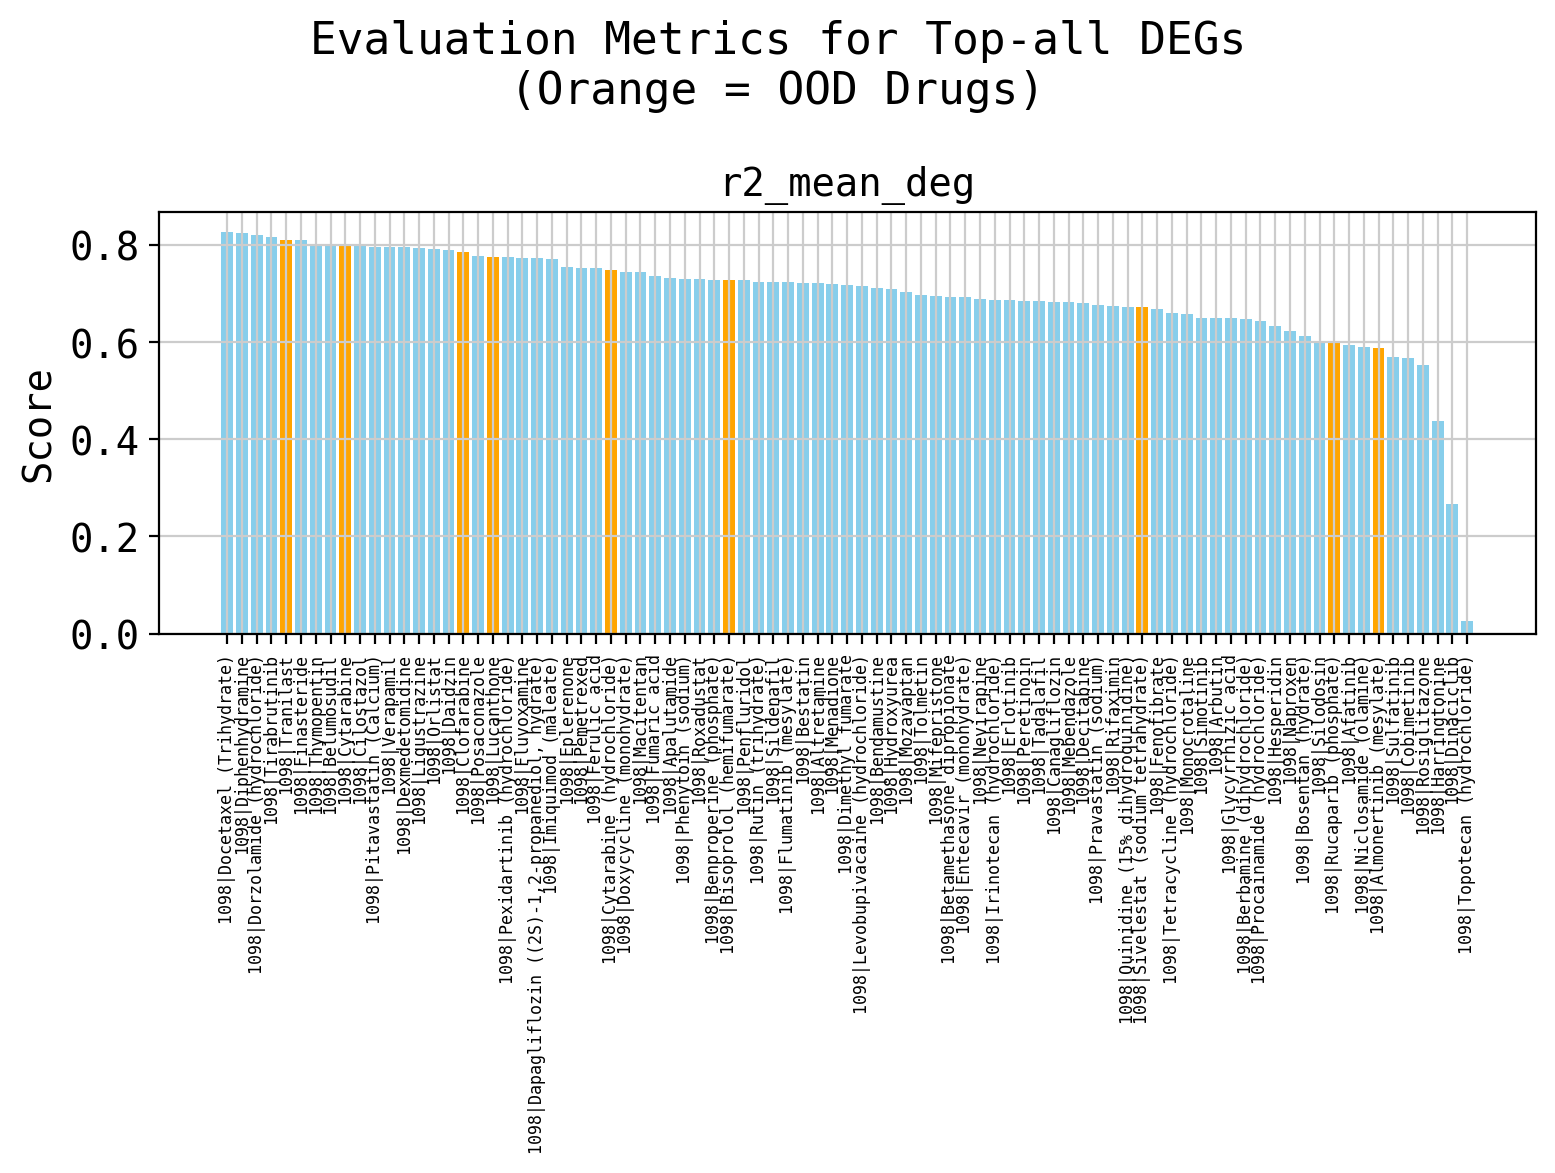

In [188]:
deg_to_plot = "all"
df_filtered = df[df["n_top_deg"] == deg_to_plot].copy()

# Normalize OOD drug condition names (if needed)
ood_cond_names = [c.split('|')[-1].split('_')[0] for c in ood_conds]

# Mark whether each row's drug is OOD
df_filtered["is_ood"] = df_filtered["condition"].apply(lambda c: any(ood in c for ood in ood_cond_names))

# Metrics to plot
metrics = ["r2_mean_deg"]
n_metrics = len(metrics)
# Plot settings
fig, axes = plt.subplots(nrows=1, ncols=n_metrics, figsize=(8 * n_metrics, 6))
if n_metrics == 1:
    axes = [axes] 

for i, metric in enumerate(metrics):
    ax = axes[i]
    sorted_df = df_filtered.sort_values(metric, ascending=(metric.startswith("rmse") or metric == "e_distance"))

    colors = ["orange" if is_ood else "skyblue" for is_ood in sorted_df["is_ood"]]

    ax.bar(sorted_df["condition"], sorted_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df["condition"], rotation=90, fontsize=6)
    ax.set_ylabel("Score")

fig.suptitle(f"Evaluation Metrics for Top-{deg_to_plot} DEGs\n(Orange = OOD Drugs)", fontsize=16)
plt.tight_layout()
plt.show()

In [205]:
# Filter only OOD drugs
ood_df = df_filtered[df_filtered["is_ood"]]
print(ood_df[["condition", "r2_mean_deg"]])


                                 condition  r2_mean_deg
3    1098|Sivelestat (sodium tetrahydrate)     0.671417
43            1098|Almonertinib (mesylate)     0.588129
51              1098|Rucaparib (phosphate)     0.601091
75                         1098|Cytarabine     0.801067
91                         1098|Lucanthone     0.775759
227         1098|Bisoprolol (hemifumarate)     0.727037
247        1098|Cytarabine (hydrochloride)     0.749187
283                       1098|Clofarabine     0.786244
303                         1098|Tranilast     0.810997


### RMSE 
RMSE is calculated by taking the square root of the average of the squared differences between predicted and actual values. A smaller RMSE indicates better model performance.

In [190]:
mean_rmse_all = df['rmse_mean'].mean()
print("Mean RMSE across all drugs:", mean_rmse_all)

Mean RMSE across all drugs: 0.12284806210446


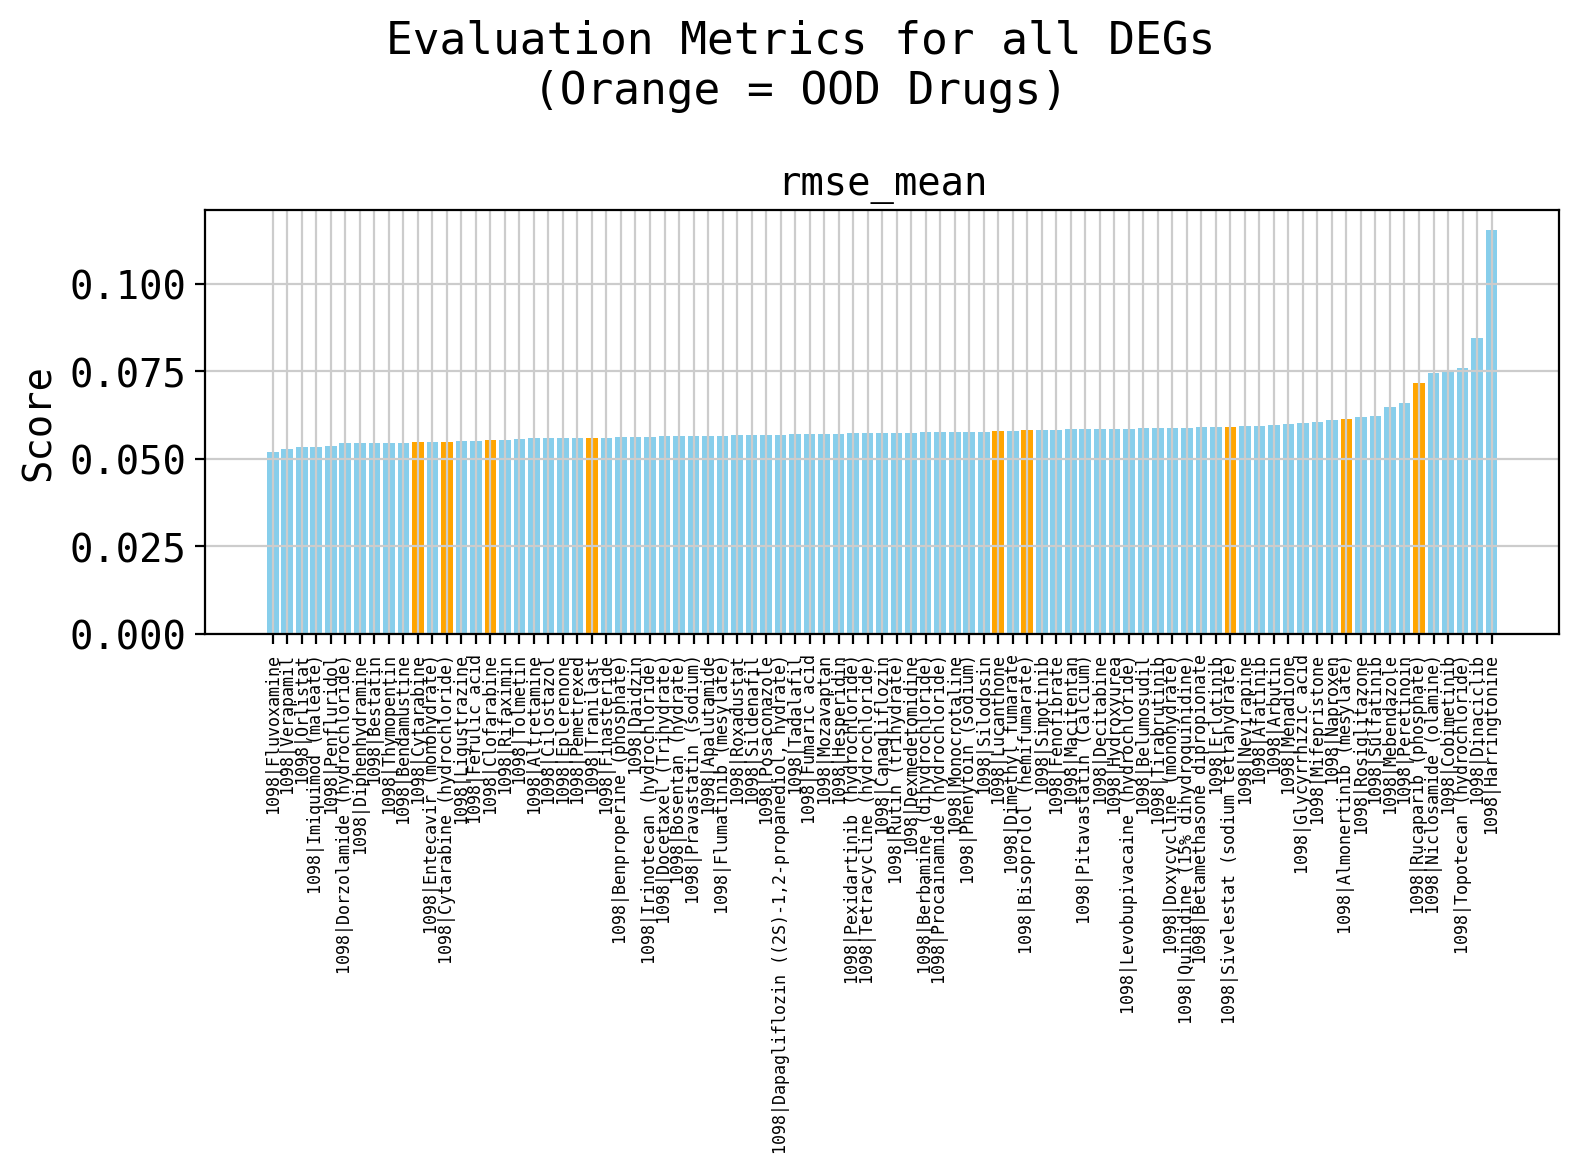

In [191]:
deg_to_plot = 'all'
df_filtered = df[df["n_top_deg"] == deg_to_plot].copy()

# Normalize OOD drug condition names (if needed)
ood_cond_names = [c.split('|')[-1].split('_')[0] for c in ood_conds]

# Mark whether each row's drug is OOD
df_filtered["is_ood"] = df_filtered["condition"].apply(lambda c: any(ood in c for ood in ood_cond_names))

# Metrics to plot
metrics = ["rmse_mean"]
n_metrics = len(metrics)
# Plot settings
fig, axes = plt.subplots(nrows=1, ncols=n_metrics, figsize=(8 * n_metrics, 6))
if n_metrics == 1:
    axes = [axes] 

for i, metric in enumerate(metrics):
    ax = axes[i]
    sorted_df = df_filtered.sort_values(metric, ascending=(metric.startswith("rmse") or metric == "e_distance"))

    colors = ["orange" if is_ood else "skyblue" for is_ood in sorted_df["is_ood"]]

    ax.bar(sorted_df["condition"], sorted_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df["condition"], rotation=90, fontsize=6)
    ax.set_ylabel("Score")

fig.suptitle(f"Evaluation Metrics for {deg_to_plot} DEGs\n(Orange = OOD Drugs)", fontsize=16)   #or Top
plt.tight_layout()
plt.show()

In [192]:
print(ood_df[["condition", "rmse_mean"]])

                                 condition  rmse_mean
3    1098|Sivelestat (sodium tetrahydrate)   0.059166
43            1098|Almonertinib (mesylate)   0.061347
51              1098|Rucaparib (phosphate)   0.071710
75                         1098|Cytarabine   0.054664
91                         1098|Lucanthone   0.057859
227         1098|Bisoprolol (hemifumarate)   0.058245
247        1098|Cytarabine (hydrochloride)   0.054751
283                       1098|Clofarabine   0.055278
303                         1098|Tranilast   0.056054


### Cosine similarity 
Measures the angle between two vectors, which compares predicted vs observed log fold-change (LFC) profiles of gene expression. 
-1 ≤ cosine similarity ≤ 1   Perfect alignment (predicted and observed profiles have the same direction and shape. )



In [193]:
mean_cosine = df['cosine_sim'].mean()
print("Mean Cosine Similarity across all drugs:", mean_cosine)

Mean Cosine Similarity across all drugs: 0.6676348348182407


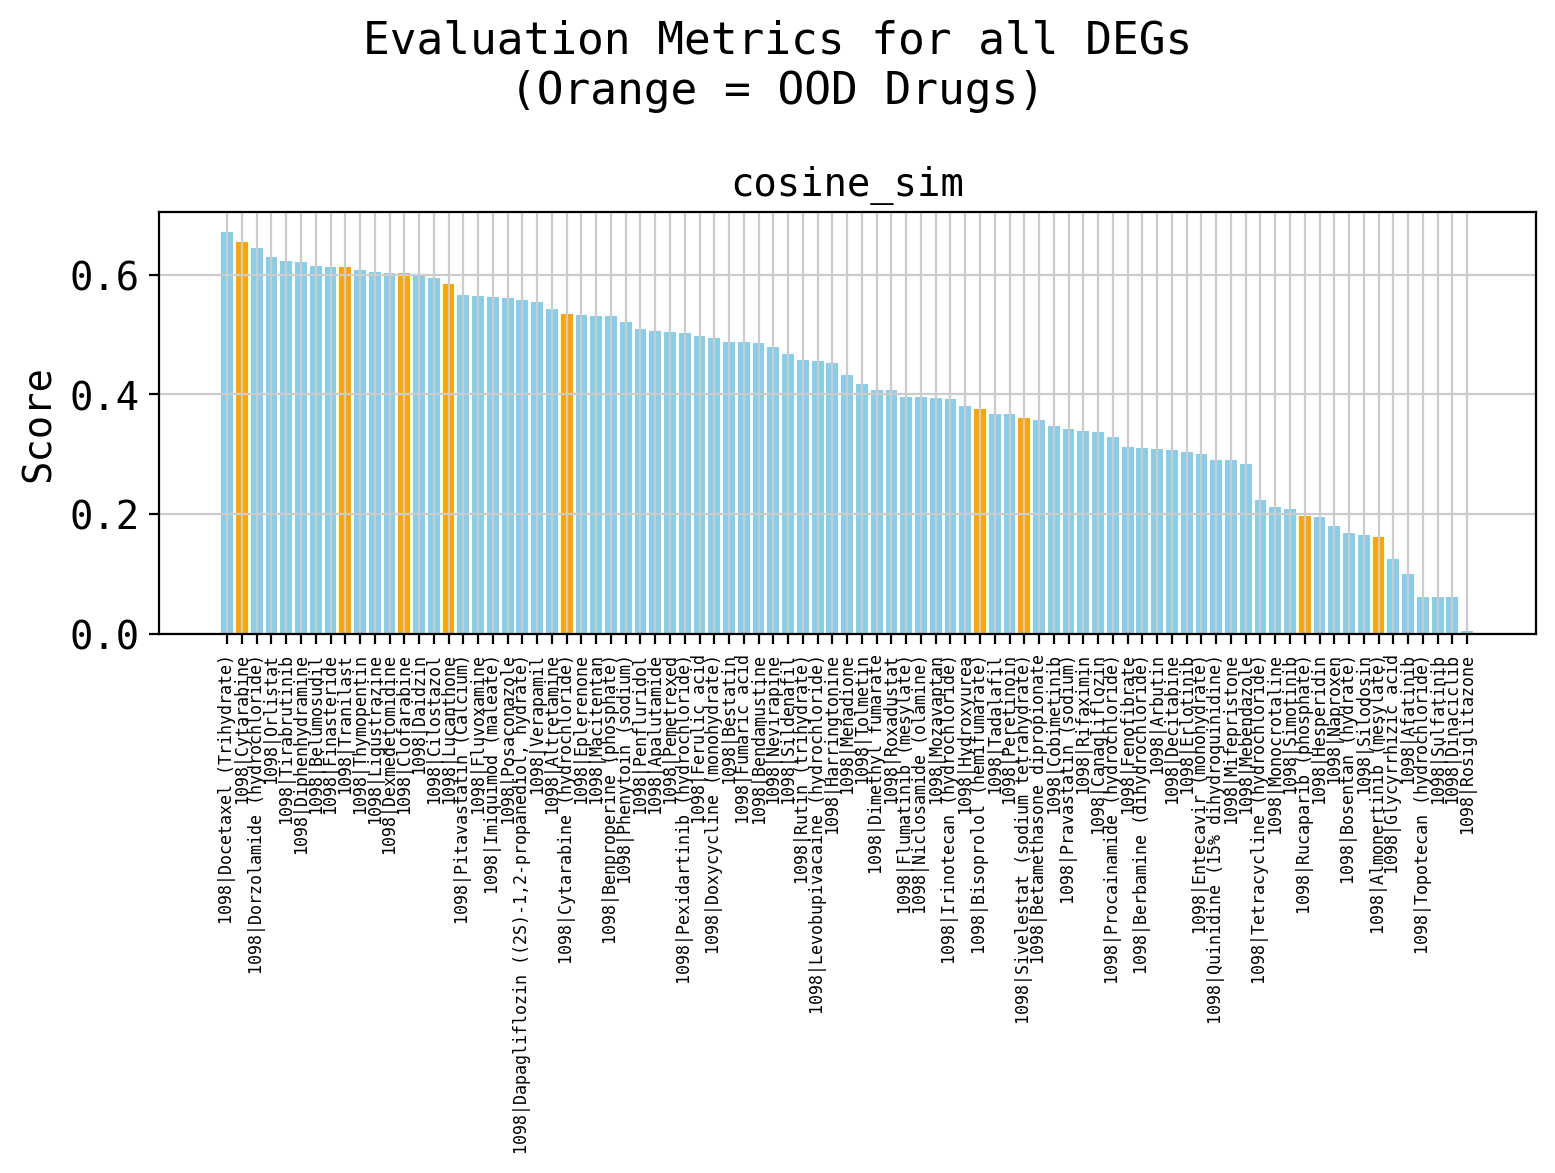

In [194]:
deg_to_plot = 'all'
df_filtered = df[df["n_top_deg"] == deg_to_plot].copy()

# Normalize OOD drug condition names (if needed)
ood_cond_names = [c.split('|')[-1].split('_')[0] for c in ood_conds]

# Mark whether each row's drug is OOD
df_filtered["is_ood"] = df_filtered["condition"].apply(lambda c: any(ood in c for ood in ood_cond_names))

# Metrics to plot
metrics = ["cosine_sim"]
n_metrics = len(metrics)
# Plot settings
fig, axes = plt.subplots(nrows=1, ncols=n_metrics, figsize=(8 * n_metrics, 6))
if n_metrics == 1:
    axes = [axes] 

for i, metric in enumerate(metrics):
    ax = axes[i]
    sorted_df = df_filtered.sort_values(metric, ascending=(metric.startswith("rmse") or metric == "e_distance"))

    colors = ["orange" if is_ood else "skyblue" for is_ood in sorted_df["is_ood"]]

    ax.bar(sorted_df["condition"], sorted_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df["condition"], rotation=90, fontsize=6)
    ax.set_ylabel("Score")

fig.suptitle(f"Evaluation Metrics for {deg_to_plot} DEGs\n(Orange = OOD Drugs)", fontsize=16)   #or Top
plt.tight_layout()
plt.show()

In [195]:
# Filter only OOD drugs
ood_df = df_filtered[df_filtered["is_ood"]]

# Select only the condition and cosine similarity columns
print(ood_df[["condition", "cosine_sim"]])


                                 condition  cosine_sim
3    1098|Sivelestat (sodium tetrahydrate)    0.360771
43            1098|Almonertinib (mesylate)    0.161954
51              1098|Rucaparib (phosphate)    0.195761
75                         1098|Cytarabine    0.654183
91                         1098|Lucanthone    0.584094
227         1098|Bisoprolol (hemifumarate)    0.375475
247        1098|Cytarabine (hydrochloride)    0.533772
283                       1098|Clofarabine    0.601941
303                         1098|Tranilast    0.611847


In [196]:
mean_cosine_ood = df['cosine_sim'].mean()
print("Mean Cosine Similarity across OOD drugs:", mean_cosine_ood)

Mean Cosine Similarity across OOD drugs: 0.6676348348182407


###  E-distance (energy distance)

Distance between two probability distributions (e.g., predicted vs observed gene expression distributions).

Smaller values close to 0 indicate good alighnment.

In [197]:
mean_e_dist = df['e_distance'].mean()
print("Mean E-Distance across all drugs:", mean_e_dist)

Mean E-Distance across all drugs: 0.16176560900512835


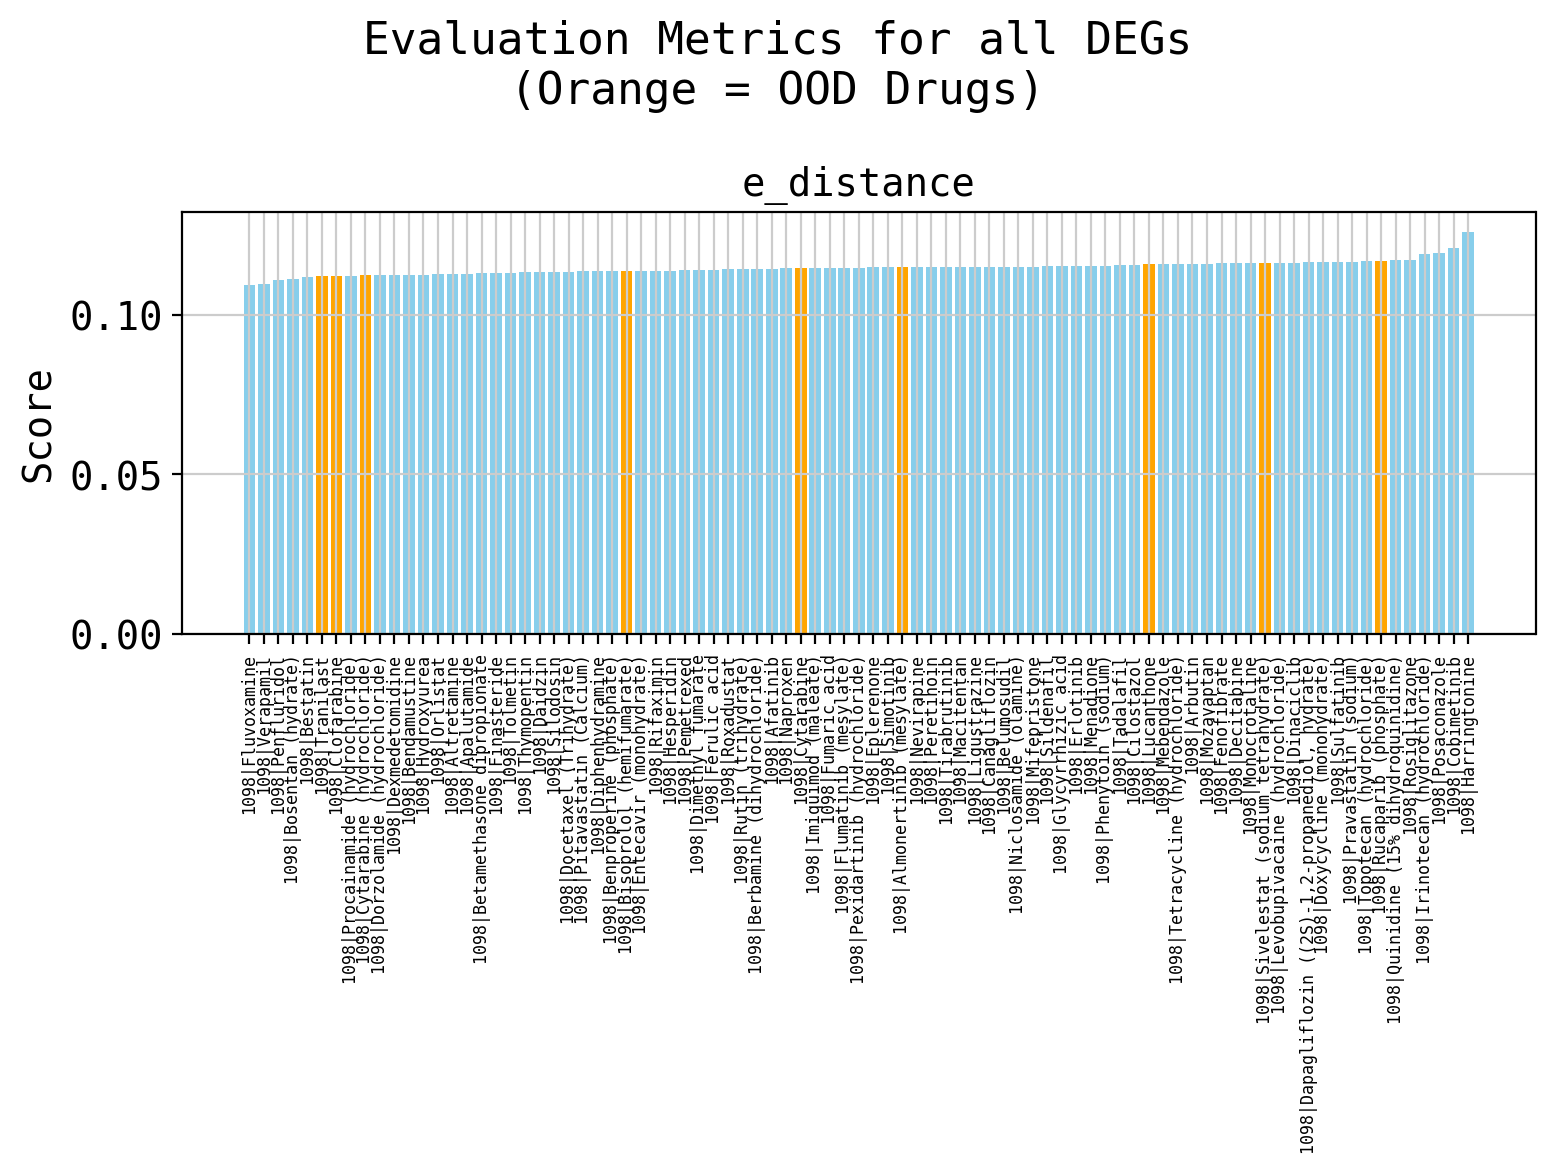

In [198]:
deg_to_plot = 'all'
df_filtered = df[df["n_top_deg"] == deg_to_plot].copy()

# Normalize OOD drug condition names (if needed)
ood_cond_names = [c.split('|')[-1].split('_')[0] for c in ood_conds]

# Mark whether each row's drug is OOD
df_filtered["is_ood"] = df_filtered["condition"].apply(lambda c: any(ood in c for ood in ood_cond_names))

# Metrics to plot
metrics = ["e_distance"]
n_metrics = len(metrics)
# Plot settings
fig, axes = plt.subplots(nrows=1, ncols=n_metrics, figsize=(8 * n_metrics, 6))
if n_metrics == 1:
    axes = [axes] 

for i, metric in enumerate(metrics):
    ax = axes[i]
    sorted_df = df_filtered.sort_values(metric, ascending=(metric.startswith("rmse") or metric == "e_distance"))

    colors = ["orange" if is_ood else "skyblue" for is_ood in sorted_df["is_ood"]]

    ax.bar(sorted_df["condition"], sorted_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df["condition"], rotation=90, fontsize=6)
    ax.set_ylabel("Score")

fig.suptitle(f"Evaluation Metrics for {deg_to_plot} DEGs\n(Orange = OOD Drugs)", fontsize=16)   #or Top
plt.tight_layout()
plt.show()

In [199]:
# Filter only OOD drugs
ood_df = df_filtered[df_filtered["is_ood"]]
print(ood_df[["condition", "e_distance"]])


                                 condition  e_distance
3    1098|Sivelestat (sodium tetrahydrate)    0.116346
43            1098|Almonertinib (mesylate)    0.114906
51              1098|Rucaparib (phosphate)    0.116965
75                         1098|Cytarabine    0.114590
91                         1098|Lucanthone    0.115940
227         1098|Bisoprolol (hemifumarate)    0.113711
247        1098|Cytarabine (hydrochloride)    0.112369
283                       1098|Clofarabine    0.112170
303                         1098|Tranilast    0.112042


## Visualizing similarity between drug embeddings

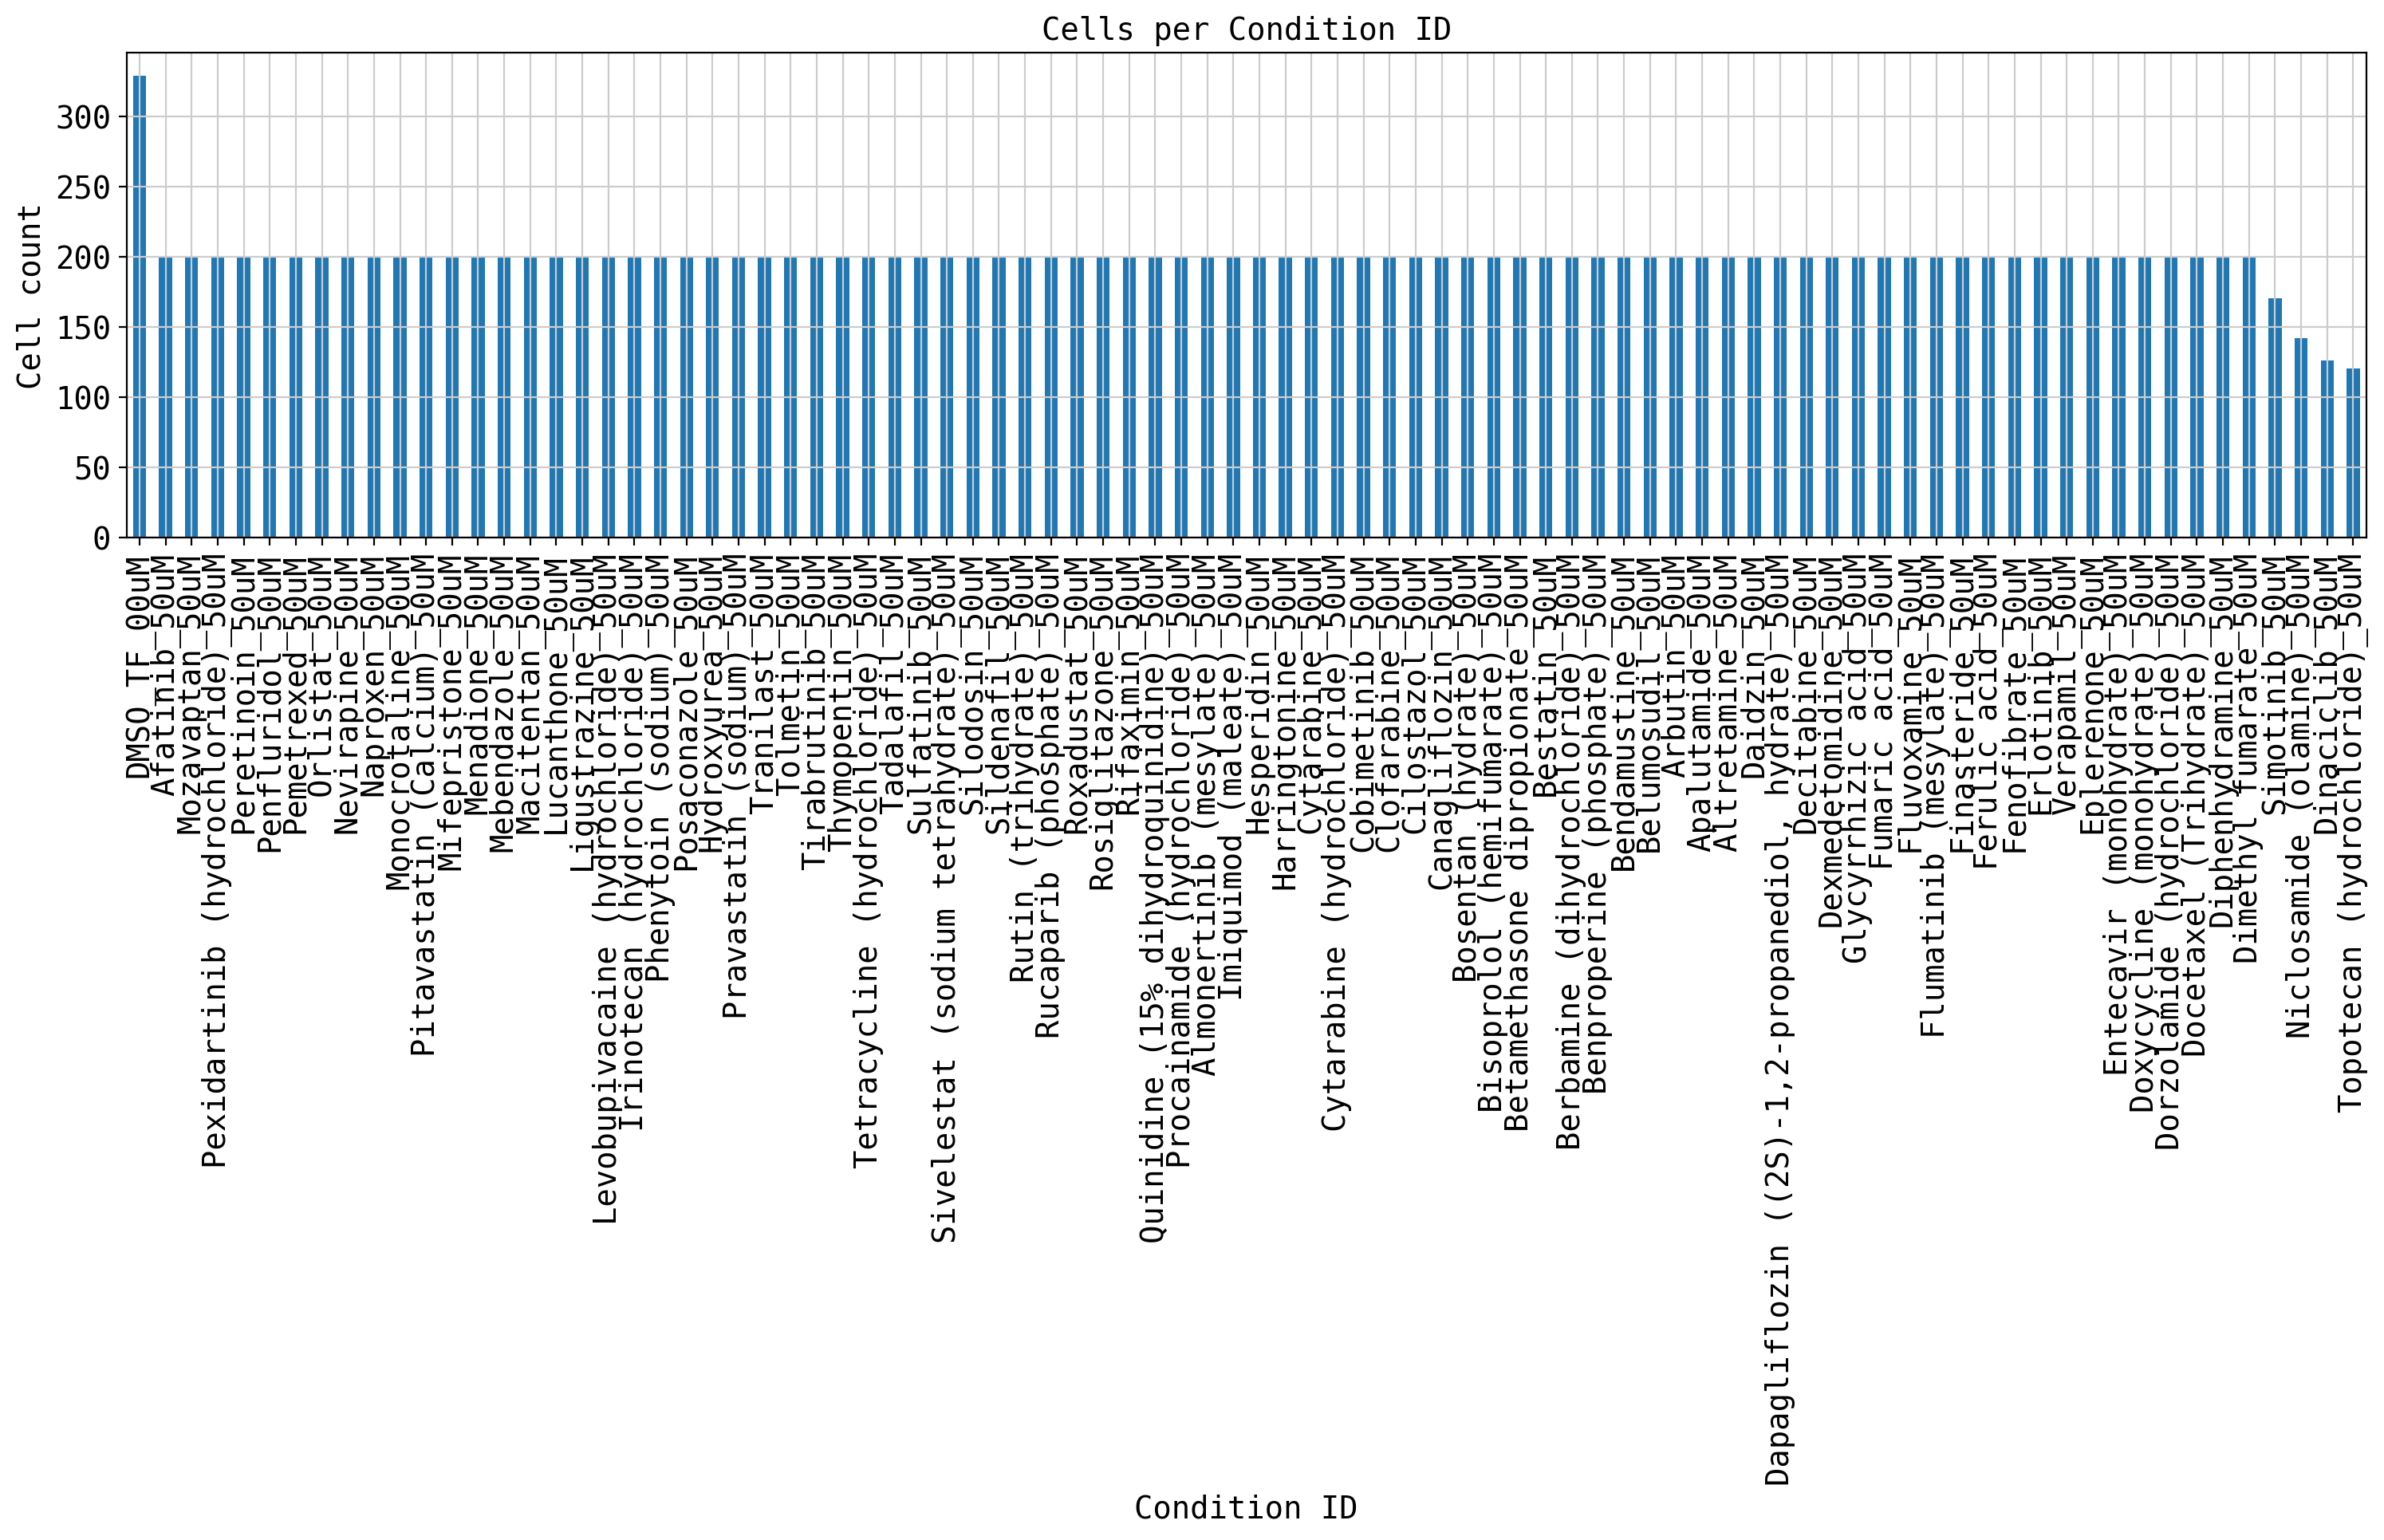

In [200]:
# Count cells per condition_ID
condition_counts = adata.obs['condition_ID'].value_counts()

# Plot
condition_counts.plot.bar(figsize=(18, 4), title='Cells per Condition ID')
plt.ylabel('Cell count')
plt.xlabel('Condition ID')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
